
Q1. First 10 Records:
    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428      A     Yangon        Member  Female   
1  226-31-3081      C  Naypyitaw        Normal  Female   
2  631-41-3108      A     Yangon        Normal    Male   
3  123-19-1176      A     Yangon        Member    Male   
4  373-73-7910      A     Yangon        Normal    Male   
5  699-14-3026      C  Naypyitaw        Normal    Male   
6  355-53-5943      A     Yangon        Member  Female   
7  315-22-5665      C  Naypyitaw        Normal  Female   
8  665-32-9167      A     Yangon        Member  Female   
9  692-92-5582      B   Mandalay        Member  Female   

             Product line  Unit price  Quantity   Tax 5%     Total       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health

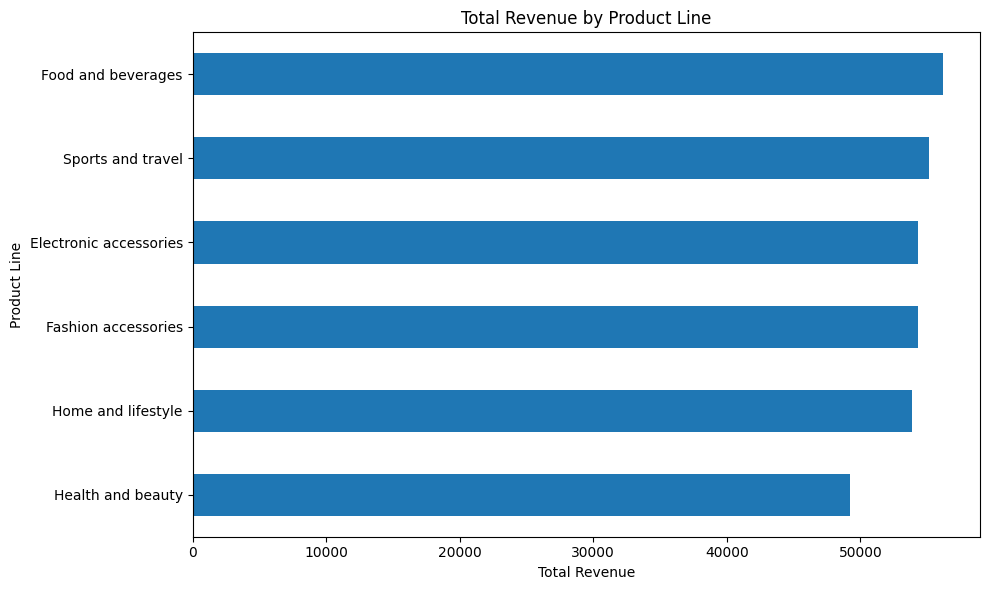

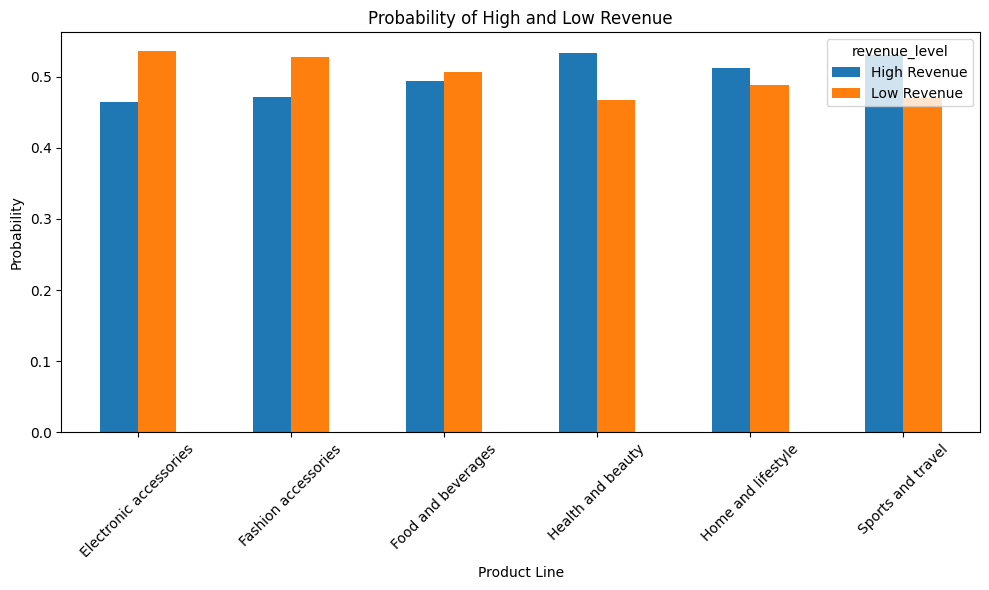


Q20. Highest Probability of High Revenue:
Health and beauty = 0.5329


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("supermarket_sales.csv")

# Q1. Display first 10 records
print("\nQ1. First 10 Records:")
print(df.head(10))

# Create revenue column using Total
df["revenue"] = df["Total"]

# Q2. Dataset information
print("\nQ2. Dataset Information:")
print("Number of Records:", df.shape[0])
print("Number of Columns:", df.shape[1])
print("Column Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)

# Q3. Unique product lines
print("\nQ3. Unique Product Lines:")
print(df["Product line"].unique())

# Q4. Total revenue by product line
total_revenue = df.groupby("Product line")["revenue"].sum()
print("\nQ4. Total Revenue by Product Line:")
print(total_revenue)

# Q5. Average revenue by product line
average_revenue = df.groupby("Product line")["revenue"].mean()
print("\nQ5. Average Revenue by Product Line:")
print(average_revenue)

# Q6. Total quantity sold by product line
total_quantity = df.groupby("Product line")["Quantity"].sum()
print("\nQ6. Total Quantity Sold:")
print(total_quantity)

# Q7. Median revenue
median_revenue = df["revenue"].median()
print("\nQ7. Median Revenue:", median_revenue)

# Q8. Classify transactions
df["revenue_level"] = df["revenue"].apply(
    lambda x: "High Revenue" if x >= median_revenue else "Low Revenue"
)

# Q9. Display revenue_level
print("\nQ9. Revenue Level:")
print(df[["revenue", "revenue_level"]].head(10))

# Q10. Number of High/Low transactions
count_table = pd.crosstab(df["Product line"], df["revenue_level"])
print("\nQ10. High and Low Revenue Transactions:")
print(count_table)

# Q11. Probability of High/Low Revenue
probability_table = count_table.div(count_table.sum(axis=1), axis=0)
print("\nQ11. Revenue Probabilities:")
print(probability_table)

# Q12. Verify probabilities add to 1
probability_sum = probability_table.sum(axis=1)
print("\nQ12. Probability Sum:")
print(probability_sum)

# Q13. Average revenue for High/Low Revenue
payoff_table = df.groupby(
    ["Product line", "revenue_level"]
)["revenue"].mean().unstack()

print("\nQ13. Average Revenue / Payoff:")
print(payoff_table)

# Q14. Create DataFrame with Product Line, Revenue Level,
# Probability and Payoff
decision_data = []

for product in probability_table.index:
    for level in probability_table.columns:
        decision_data.append([
            product,
            level,
            probability_table.loc[product, level],
            payoff_table.loc[product, level]
        ])

decision_df = pd.DataFrame(
    decision_data,
    columns=["Product Line", "Revenue Level", "Probability", "Payoff"]
)

print("\nQ14. Decision DataFrame:")
print(decision_df)

# Q15. Decision alternatives and uncertain outcomes
print("\nQ15. Decision Alternatives:")
print(probability_table.index.tolist())

print("\nUncertain Outcomes:")
print(probability_table.columns.tolist())

# Q16 & Q17. Decision Tree Data
print("\nQ16-Q17. Decision Tree:")
for product in probability_table.index:
    print("\nDecision:", product)
    for level in probability_table.columns:
        print(
            "  ->", level,
            "| Probability:", round(probability_table.loc[product, level], 4),
            "| Payoff:", round(payoff_table.loc[product, level], 2)
        )

# Q18. Total Revenue Visualization
plt.figure(figsize=(10, 6))
total_revenue.sort_values().plot(kind="barh")
plt.title("Total Revenue by Product Line")
plt.xlabel("Total Revenue")
plt.ylabel("Product Line")
plt.tight_layout()
plt.show()

# Q19. Probability Visualization
probability_table.plot(
    kind="bar",
    figsize=(10, 6)
)
plt.title("Probability of High and Low Revenue")
plt.xlabel("Product Line")
plt.ylabel("Probability")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Q20. Highest probability of High Revenue
highest_high_probability = probability_table["High Revenue"].idxmax()
highest_probability = probability_table["High Revenue"].max()

print("\nQ20. Highest Probability of High Revenue:")
print(highest_high_probability, "=", round(highest_probability, 4))


Q21. Expected Value:
Expected Value is used to compare different product lines.
The product line with the highest Expected Value is selected.

Q22. Formula:
EV = (P(High Revenue) × High Revenue Payoff) +
     (P(Low Revenue) × Low Revenue Payoff)

Q23. Expected Value of Electronic accessories :
319.63

Q24. Expected Value for Every Product Line:
Product line
Electronic accessories    319.63
Fashion accessories       305.09
Food and beverages        322.67
Health and beauty         323.64
Home and lifestyle        336.64
Sports and travel         332.07
dtype: float64

Q25. Expected Value DataFrame:
             Product Line  High Revenue Probability  High Revenue Payoff  \
0  Electronic accessories                      0.46               537.01   
1     Fashion accessories                      0.47               512.33   
2      Food and beverages                      0.49               515.13   
3       Health and beauty                      0.53               497.22   
4      Home a

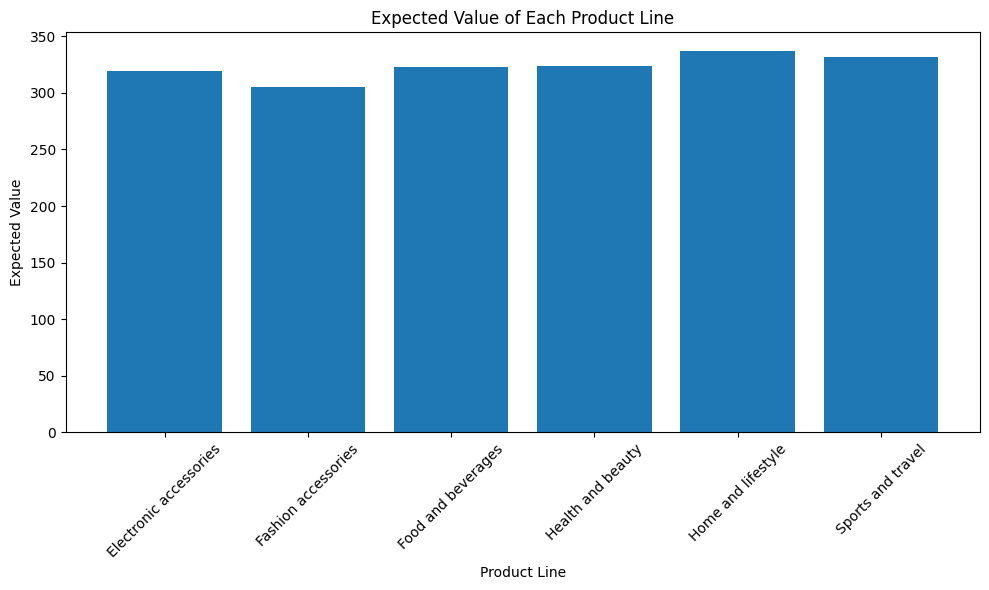


Q31. Comparison:
Highest probability of High Revenue: Health and beauty
Highest Expected Value: Home and lifestyle

Q32. Result:
No, they are different product lines.

Q33. Changed Probability:
Product Line: Home and lifestyle
New High Revenue Probability: 0.6125
New Low Revenue Probability: 0.3875
New Expected Value: 376.22

Q34. Changed Payoff:
Product Line: Home and lifestyle
New High Revenue Payoff: 579.58
New Expected Value: 362.26

Q35. Automatic Decision:
Selected Product Line: Home and lifestyle
Highest Expected Value: 336.64

Q36. Final Decision Tree:

 Electronic accessories
  ├── High Revenue | Probability: 0.4647 | Payoff: 537.01
  └── Low Revenue  | Probability: 0.5353 | Payoff: 130.92
  Expected Value: 319.63

 Fashion accessories
  ├── High Revenue | Probability: 0.4719 | Payoff: 512.33
  └── Low Revenue  | Probability: 0.5281 | Payoff: 119.9
  Expected Value: 305.09

 Food and beverages
  ├── High Revenue | Probability: 0.4943 | Payoff: 515.13
  └── Low Revenue  | Prob

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("supermarket_sales.csv")

# Use Total as Revenue
df["revenue"] = df["Total"]

# Calculate median revenue
median_revenue = df["revenue"].median()

# Classify revenue
df["revenue_level"] = df["revenue"].apply(
    lambda x: "High Revenue" if x >= median_revenue else "Low Revenue"
)

# Calculate probabilities
count_table = pd.crosstab(df["Product line"], df["revenue_level"])
probability_table = count_table.div(count_table.sum(axis=1), axis=0)

# Calculate payoffs
payoff_table = df.groupby(
    ["Product line", "revenue_level"]
)["revenue"].mean().unstack()

# PART B: APPLY EXPECTED VALUE

# Q21. Explain Expected Value
print("\nQ21. Expected Value:")
print("Expected Value is used to compare different product lines.")
print("The product line with the highest Expected Value is selected.")

# Q22. Formula
print("\nQ22. Formula:")
print("EV = (P(High Revenue) × High Revenue Payoff) +")
print("     (P(Low Revenue) × Low Revenue Payoff)")

# Q23. Calculate Expected Value of one product line
product = probability_table.index[0]

high_probability = probability_table.loc[product, "High Revenue"]
low_probability = probability_table.loc[product, "Low Revenue"]

high_payoff = payoff_table.loc[product, "High Revenue"]
low_payoff = payoff_table.loc[product, "Low Revenue"]

ev_one = (high_probability * high_payoff) + \
         (low_probability * low_payoff)

print("\nQ23. Expected Value of", product, ":")
print(round(ev_one, 2))

# Q24. Calculate Expected Value for every product line
expected_values = (
    probability_table["High Revenue"] * payoff_table["High Revenue"]
    + probability_table["Low Revenue"] * payoff_table["Low Revenue"]
)

print("\nQ24. Expected Value for Every Product Line:")
print(expected_values.round(2))

# Q25. Create Expected Value DataFrame
ev_df = pd.DataFrame({
    "Product Line": probability_table.index,
    "High Revenue Probability":
        probability_table["High Revenue"].values,
    "High Revenue Payoff":
        payoff_table["High Revenue"].values,
    "Low Revenue Probability":
        probability_table["Low Revenue"].values,
    "Low Revenue Payoff":
        payoff_table["Low Revenue"].values,
    "Expected Value":
        expected_values.values
})

print("\nQ25. Expected Value DataFrame:")
print(ev_df.round(2))

# Q26. Compare Expected Values
print("\nQ26. Comparison of Expected Values:")
print(
    ev_df[["Product Line", "Expected Value"]]
    .sort_values("Expected Value", ascending=False)
    .round(2)
)

# Q27. Highest Expected Value
highest_ev = ev_df.loc[ev_df["Expected Value"].idxmax()]

print("\nQ27. Highest Expected Value:")
print("Product Line:", highest_ev["Product Line"])
print("Expected Value:", round(highest_ev["Expected Value"], 2))

# Q28. Lowest Expected Value
lowest_ev = ev_df.loc[ev_df["Expected Value"].idxmin()]

print("\nQ28. Lowest Expected Value:")
print("Product Line:", lowest_ev["Product Line"])
print("Expected Value:", round(lowest_ev["Expected Value"], 2))

# Q29. Rank Product Lines
ranking = ev_df.sort_values(
    "Expected Value",
    ascending=False
).reset_index(drop=True)

ranking["Rank"] = ranking.index + 1

print("\nQ29. Ranking:")
print(
    ranking[
        ["Rank", "Product Line", "Expected Value"]
    ].round(2)
)

# Q30. Bar Chart of Expected Values
plt.figure(figsize=(10, 6))
plt.bar(
    ev_df["Product Line"],
    ev_df["Expected Value"]
)
plt.title("Expected Value of Each Product Line")
plt.xlabel("Product Line")
plt.ylabel("Expected Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Q31. Compare highest High Revenue probability
highest_probability_product = probability_table[
    "High Revenue"
].idxmax()

highest_ev_product = expected_values.idxmax()

print("\nQ31. Comparison:")
print(
    "Highest probability of High Revenue:",
    highest_probability_product
)
print(
    "Highest Expected Value:",
    highest_ev_product
)

# Q32. Are they the same?
print("\nQ32. Result:")

if highest_probability_product == highest_ev_product:
    print(
        "Yes, both are the same product line."
    )
else:
    print(
        "No, they are different product lines."
    )

# Q33. Change probability and recalculate EV
product = highest_ev_product

old_high_probability = probability_table.loc[
    product, "High Revenue"
]

new_high_probability = old_high_probability + 0.10

if new_high_probability > 1:
    new_high_probability = 1

new_low_probability = 1 - new_high_probability

new_ev_probability = (
    new_high_probability *
    payoff_table.loc[product, "High Revenue"]
    +
    new_low_probability *
    payoff_table.loc[product, "Low Revenue"]
)

print("\nQ33. Changed Probability:")
print("Product Line:", product)
print(
    "New High Revenue Probability:",
    round(new_high_probability, 4)
)
print(
    "New Low Revenue Probability:",
    round(new_low_probability, 4)
)
print(
    "New Expected Value:",
    round(new_ev_probability, 2)
)

# Q34. Change payoff and recalculate EV
old_high_payoff = payoff_table.loc[
    product, "High Revenue"
]

new_high_payoff = old_high_payoff + 50

new_ev_payoff = (
    probability_table.loc[product, "High Revenue"]
    * new_high_payoff
    +
    probability_table.loc[product, "Low Revenue"]
    * payoff_table.loc[product, "Low Revenue"]
)

print("\nQ34. Changed Payoff:")
print("Product Line:", product)
print(
    "New High Revenue Payoff:",
    round(new_high_payoff, 2)
)
print(
    "New Expected Value:",
    round(new_ev_payoff, 2)
)

# Q35. Automatically select product with highest EV
best_product = expected_values.idxmax()
best_ev = expected_values.max()

print("\nQ35. Automatic Decision:")
print("Selected Product Line:", best_product)
print("Highest Expected Value:", round(best_ev, 2))

# Q36. Final Decision Tree with Expected Value
print("\nQ36. Final Decision Tree:")

for product in probability_table.index:

    print("\n", product)

    print(
        "  ├── High Revenue | Probability:",
        round(
            probability_table.loc[
                product, "High Revenue"
            ], 4
        ),
        "| Payoff:",
        round(
            payoff_table.loc[
                product, "High Revenue"
            ], 2
        )
    )

    print(
        "  └── Low Revenue  | Probability:",
        round(
            probability_table.loc[
                product, "Low Revenue"
            ], 4
        ),
        "| Payoff:",
        round(
            payoff_table.loc[
                product, "Low Revenue"
            ], 2
        )
    )

    print(
        "  Expected Value:",
        round(expected_values.loc[product], 2)
    )

# Q37. Business Recommendation
print("\nQ37. Business Recommendation:")

print(
    "The recommended product line is",
    best_product,
    "because it has the highest Expected Value of",
    round(best_ev, 2),
    "."
)